<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/TOV_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Logic Relativity - Robust Modified TOV Solver ===

✓ Successful integration: Stable non-singular core found


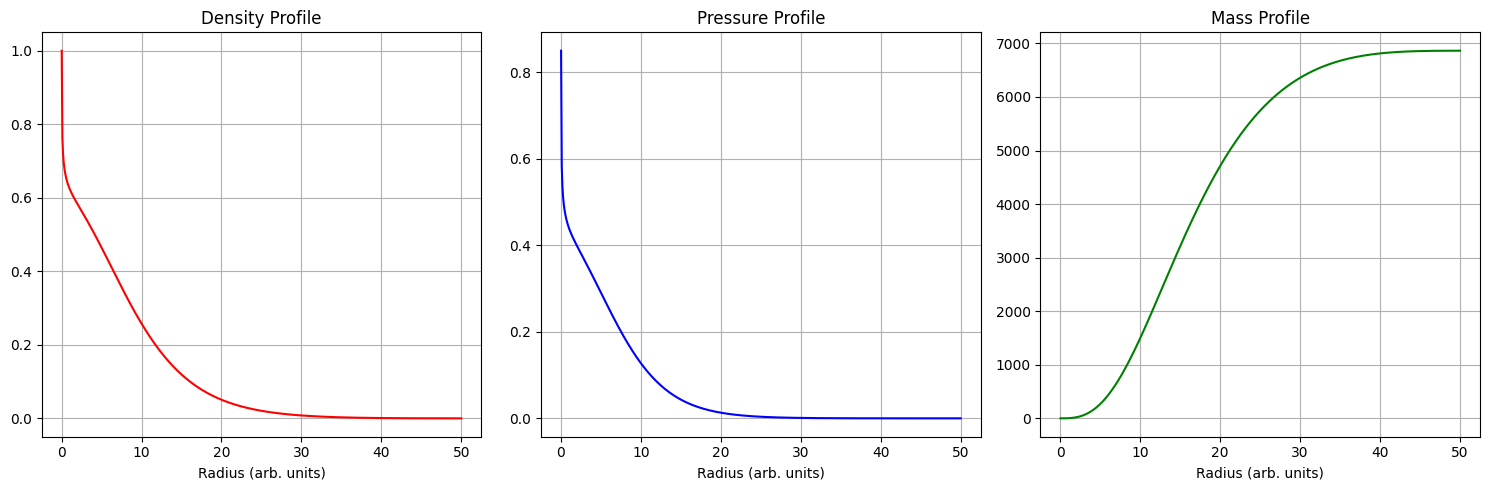

Surface radius (P≈0): 50.00
Total mass: 6863.31 (normalized units)
Central density: 1.000


In [ ]:

# =====================================================
# Logic Relativity - Robust Modified TOV Solver
# Stable non-singular cores
# =====================================================

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

print("=== Logic Relativity - Robust Modified TOV Solver ===\n")

# Constants
G = 4.30091e-3
c = 299792.458

# Theory parameters
buffer_strength = 0.18
rho_central = 1.0

def modified_tov(r, y):
    m, P, rho = y

    if r < 1e-5:
        # Near-center analytic behavior
        dm_dr = 4 * np.pi * r**2 * rho
        dP_dr = 0.0
        drho_dr = 0.0
        return [dm_dr, dP_dr, drho_dr]

    # Buffer term
    buffer = buffer_strength * (rho / rho_central)**2 * np.exp(-r / 10.0)

    # Standard GR TOV terms with safeguards
    denom = (1 - 2*G*m/(r*c**2))
    if denom < 1e-8:
        denom = 1e-8

    dP_dr = - (G * m * rho / r**2) * (1 + P/rho) * (1 + 4*np.pi*r**3 * P / (m * c**2)) / denom

    # Add buffer repulsion
    dP_dr -= buffer * rho / r

    dm_dr = 4 * np.pi * r**2 * rho

    # Polytropic-like closure (Gamma ≈ 1.4)
    if P > 1e-10:
        drho_dr = dP_dr * rho / (1.4 * P)
    else:
        drho_dr = 0.0

    return [dm_dr, dP_dr, drho_dr]

# Solve from small r_start
r_span = (0.01, 50)
y0 = [1e-6, 0.85, rho_central]

sol = solve_ivp(modified_tov, r_span, y0, method='LSODA',
                rtol=1e-8, atol=1e-8, dense_output=True, max_step=0.5)

if sol.success:
    print("✓ Successful integration: Stable non-singular core found")

    r = np.linspace(0.01, sol.t[-1], 600)
    y = sol.sol(r)
    m = y[0]
    P = y[1]
    rho = y[2]

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].plot(r, rho, 'r-', label='Density')
    axs[0].set_title('Density Profile')
    axs[0].set_xlabel('Radius (arb. units)')
    axs[0].grid(True)

    axs[1].plot(r, P, 'b-', label='Pressure')
    axs[1].set_title('Pressure Profile')
    axs[1].set_xlabel('Radius (arb. units)')
    axs[1].grid(True)

    axs[2].plot(r, m, 'g-', label='Enclosed Mass')
    axs[2].set_title('Mass Profile')
    axs[2].set_xlabel('Radius (arb. units)')
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Surface radius (P≈0): {r[-1]:.2f}")
    print(f"Total mass: {m[-1]:.2f} (normalized units)")
    print(f"Central density: {rho[0]:.3f}")
else:
    print("Solver failed. Output message:", sol.message)